# DNN DDoS Detection

## 0. Importing Libraries

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
# import kagglehub

## 1. Data Preprocessing

In [162]:
# path = kagglehub.dataset_download("muhammadumarjavaid/insdn-dataset-2020")

df = pd.read_csv(Path().cwd() / 'data' / 'Dataset.csv')
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,target
0,185.127.17.56-192.168.20.133-443-53648-6,185.127.17.56,443,192.168.20.133,53648,6,5/2/2020 13:58,245230,44,40,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,185.127.17.56-192.168.20.133-443-53650-6,192.168.20.133,53650,185.127.17.56,443,6,5/2/2020 13:58,1605449,107,149,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.133,35108,192.168.20.2,53,6,5/2/2020 13:58,53078,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.2,53,192.168.20.133,35108,6,5/2/2020 13:58,6975,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,154.59.122.74-192.168.20.133-443-60900-6,192.168.20.133,60900,154.59.122.74,443,6,5/2/2020 13:58,190141,13,16,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [163]:
df.describe()

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,target
count,343889.000000,343889.000000,343889.000000,3.438890e+05,343889.000000,343889.000000,3.438890e+05,3.438890e+05,343889.000000,343889.000000,...,343889.0,3.438890e+05,3.438890e+05,3.438890e+05,3.438890e+05,3.438890e+05,3.438890e+05,3.438890e+05,3.438890e+05,343889.000000
mean,21982.659541,8072.495366,4.961767,6.737171e+06,6.160331,6.119012,7.310557e+02,8.335005e+03,115.689356,4.447778,...,0.0,6.385104e+04,3.105350e+04,1.086384e+05,4.185579e+04,4.708172e+06,1.443613e+05,4.843965e+06,4.581512e+06,0.801029
std,23669.464108,16275.407358,4.862608,2.183354e+07,1554.168988,105.863392,6.965289e+04,3.429719e+05,666.519811,31.285832,...,0.0,7.852718e+05,5.035601e+05,1.220601e+06,6.672299e+05,1.616113e+07,1.653491e+06,1.641612e+07,1.604560e+07,0.399227
min,0.000000,0.000000,0.000000,-1.540000e+02,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,0.000000,0.000000,0.000000,1.700000e+01,0.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
50%,443.000000,80.000000,6.000000,2.530000e+03,0.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
75%,43920.000000,2495.000000,6.000000,1.208600e+04,2.000000,4.000000,3.000000e+01,3.000000e+01,30.000000,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
max,65518.000000,65389.000000,17.000000,1.200000e+08,910748.000000,34094.000000,3.160000e+07,1.070000e+08,64239.000000,3900.000000,...,0.0,1.040000e+08,6.830000e+07,1.040000e+08,1.040000e+08,1.200000e+08,7.300000e+07,1.200000e+08,1.200000e+08,1.000000


In [164]:
print(df.shape)
print(df['target'].value_counts(normalize=True))

(343889, 84)
target
1    0.801029
0    0.198971
Name: proportion, dtype: float64


In [165]:
print("Duplikati:", df.duplicated().sum())
print("NaN vrednosti ukupno:", df.isnull().sum().sum())

Duplikati: 1
NaN vrednosti ukupno: 0


In [166]:
constant_cols = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

print(constant_cols)

['Fwd PSH Flags', 'Fwd URG Flags', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']


In [167]:
df.drop(columns=constant_cols, inplace=True)

In [168]:
#izbacivanje identifikatora
df.drop(columns=['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Dst Port', 'Src Port', 'Protocol'], inplace=True)
df.shape

(343889, 65)

In [169]:
print("Duplikatai nakon uklanjanja identifikatora:", df.duplicated().sum())

Duplikatai nakon uklanjanja identifikatora: 159142


In [170]:
#distribucija targeta kod duplikata
dup_mask = df.duplicated(keep=False)  # keep=False označava SVE kopije

print("Target distribucija among duplicated rows:")
print(df.loc[dup_mask, 'target'].value_counts(normalize=True))

print("\nTarget distribucija among unique rows:")
print(df.loc[~dup_mask, 'target'].value_counts(normalize=True))

Target distribucija among duplicated rows:
target
1    0.967338
0    0.032662
Name: proportion, dtype: float64

Target distribucija among unique rows:
target
1    0.632636
0    0.367364
Name: proportion, dtype: float64


In [171]:
df = df.drop_duplicates()
df.shape

(184747, 65)

In [172]:
df['target'].value_counts(normalize=True)

target
1    0.652963
0    0.347037
Name: proportion, dtype: float64

In [173]:
inf_counts = df.isin([np.inf, -np.inf]).sum()
inf_counts[inf_counts > 0]

Series([], dtype: int64)

In [174]:
# train test split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=666, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(147797, 64) (36950, 64)
target
1    0.652963
0    0.347037
Name: proportion, dtype: float64
target
1    0.652963
0    0.347037
Name: proportion, dtype: float64


In [175]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147797 entries, 38885 to 140173
Data columns (total 64 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow Duration      147797 non-null  int64  
 1   Tot Fwd Pkts       147797 non-null  int64  
 2   Tot Bwd Pkts       147797 non-null  int64  
 3   TotLen Fwd Pkts    147797 non-null  float64
 4   TotLen Bwd Pkts    147797 non-null  float64
 5   Fwd Pkt Len Max    147797 non-null  int64  
 6   Fwd Pkt Len Min    147797 non-null  int64  
 7   Fwd Pkt Len Mean   147797 non-null  float64
 8   Fwd Pkt Len Std    147797 non-null  float64
 9   Bwd Pkt Len Max    147797 non-null  int64  
 10  Bwd Pkt Len Min    147797 non-null  int64  
 11  Bwd Pkt Len Mean   147797 non-null  float64
 12  Bwd Pkt Len Std    147797 non-null  float64
 13  Flow Byts/s        147797 non-null  float64
 14  Flow Pkts/s        147797 non-null  float64
 15  Flow IAT Mean      147797 non-null  float64
 16  Flo

In [176]:
flag_cols = ['Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
             'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt',
             'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt']

transform_cols = [col for col in X.columns if col not in flag_cols]

print(f"Ukupno kolona u X: {X.shape[1]}")
print(f"Flag kolone (isključene): {len(flag_cols)}")
print(f"Za Yeo-Johnson transformaciju: {len(transform_cols)}")

Ukupno kolona u X: 64
Flag kolone (isključene): 12
Za Yeo-Johnson transformaciju: 56


In [177]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)

X_train_pt = X_train.copy()
X_test_pt = X_test.copy()

X_train_pt[transform_cols] = pt.fit_transform(X_train[transform_cols])
X_test_pt[transform_cols] = pt.transform(X_test[transform_cols])

print(X_train_pt.shape, X_test_pt.shape)

(147797, 64) (36950, 64)


In [178]:
# Clipping
CLIP_VAL = 5
X_train_pt[transform_cols] = X_train_pt[transform_cols].clip(-CLIP_VAL, CLIP_VAL)
X_test_pt[transform_cols] = X_test_pt[transform_cols].clip(-CLIP_VAL, CLIP_VAL)

In [179]:
print(X_train_pt[transform_cols].describe().T[['min', 'max', 'std']].sort_values('max', ascending=False).head(15))

                       min       max       std
Bwd IAT Min      -5.000000  5.000000  0.402766
Bwd Pkts/s       -1.599288  5.000000  0.998902
Flow IAT Min     -5.000000  5.000000  0.385247
Fwd Header Len   -1.521307  5.000000  0.998633
Flow Pkts/s      -5.000000  5.000000  0.543460
Flow Byts/s      -5.000000  5.000000  0.528265
Bwd Header Len   -4.037679  5.000000  0.998277
Flow IAT Mean    -5.000000  4.707340  0.896035
Active Std       -0.221760  4.516918  1.000003
Idle Std         -0.232829  4.295071  1.000003
Fwd IAT Min      -5.000000  4.096814  0.935304
Down/Up Ratio    -1.225364  3.804614  1.000003
Bwd IAT Mean     -5.000000  3.527876  0.874290
Subflow Fwd Pkts -1.550061  3.486920  1.000003
Tot Fwd Pkts     -1.550061  3.486920  1.000003


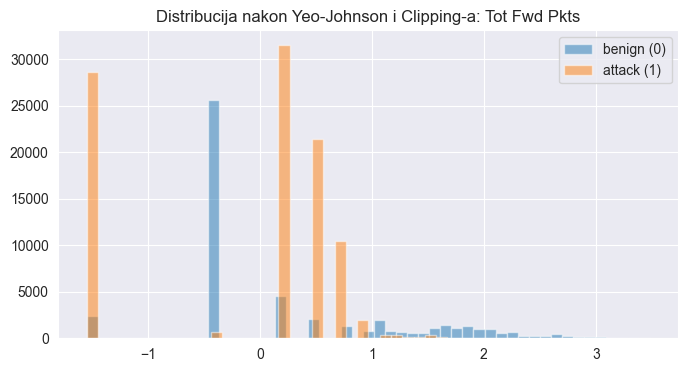

In [180]:
plt.figure(figsize=(8,4))
plt.hist(X_train_pt.loc[y_train==0, 'Tot Fwd Pkts'], bins=50, alpha=0.5, label='benign (0)')
plt.hist(X_train_pt.loc[y_train==1, 'Tot Fwd Pkts'], bins=50, alpha=0.5, label='attack (1)')
plt.legend()
plt.title('Distribucija nakon Yeo-Johnson i Clipping-a: Tot Fwd Pkts')
plt.show()

## 2. Model Training

In [181]:
def build_model(input_dim, hidden_layers=[64, 32], dropout=0.2, lr=0.001):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [182]:
input_dim = X_train_pt.shape[1]
baseline_model = build_model(input_dim)
baseline_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,273 (24.50 KB)

 Trainable params: 6,273 (24.50 KB)

 Non-trainable params: 0 (0.00 B)

In [183]:
architectures = {
    'small':        {'hidden_layers': [32, 16], 'dropout': 0.1, 'lr': 0.001},
    'medium':       {'hidden_layers': [64, 32], 'dropout': 0.2, 'lr': 0.001},
    'large':        {'hidden_layers': [128, 64, 32], 'dropout': 0.2, 'lr': 0.001},
    'wide':         {'hidden_layers': [256, 128], 'dropout': 0.3, 'lr': 0.001},
    'original_like':{'hidden_layers': [16, 256, 128], 'dropout': 0.1, 'lr': 0.0001},
    'xtra-large':   {'hidden_layers': [256, 256, 256], 'dropout': 0.05, 'lr': 0.0001},
}

results = {}

for name, params in architectures.items():
    print(f"\n--- Training: {name} ---")
    model = build_model(input_dim, **params)

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train_pt, y_train,
        epochs=15,
        batch_size=64,
        validation_data=(X_test_pt, y_test),
        callbacks=[early_stop],
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])
    n_epochs_ran = len(history.history['loss'])

    results[name] = {
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'epochs_ran': n_epochs_ran,
        'n_params': model.count_params()
    }
    print(f"{name}: val_acc={val_acc:.4f}, val_loss={val_loss:.4f}, epochs={n_epochs_ran}")

In [206]:
model = build_model(input_dim=X_train_pt.shape[1], hidden_layers=[256, 256, 256], dropout=0.1, lr=0.0001)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_pt, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test_pt, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9878 - loss: 0.0394 - val_accuracy: 0.9990 - val_loss: 0.0030
Epoch 2/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9987 - loss: 0.0047 - val_accuracy: 0.9995 - val_loss: 0.0019
Epoch 3/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 4/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 0.9993 - val_loss: 0.0016
Epoch 5/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9996 - val_loss: 0.0017
Epoch 6/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9996 - val_loss: 0.0014
Epoch 7/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.9996 - val_loss: 0.0013
Epoch 8/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9996 - loss: 0.0016 - 

## 3. Model Evaluation on Test Data

In [207]:
y_pred = (model.predict(X_test_pt) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

1155/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12823
           1       1.00      1.00      1.00     24127

    accuracy                           1.00     36950
   macro avg       1.00      1.00      1.00     36950
weighted avg       1.00      1.00      1.00     36950



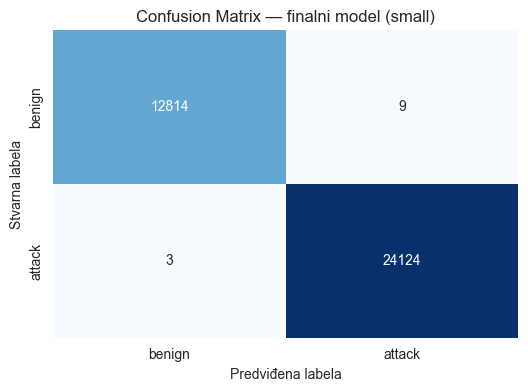

In [186]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sb.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['benign', 'attack'], yticklabels=['benign', 'attack'])
plt.title("Confusion Matrix — finalni model (small)")
plt.xlabel("Predviđena labela")
plt.ylabel("Stvarna labela")
plt.show()

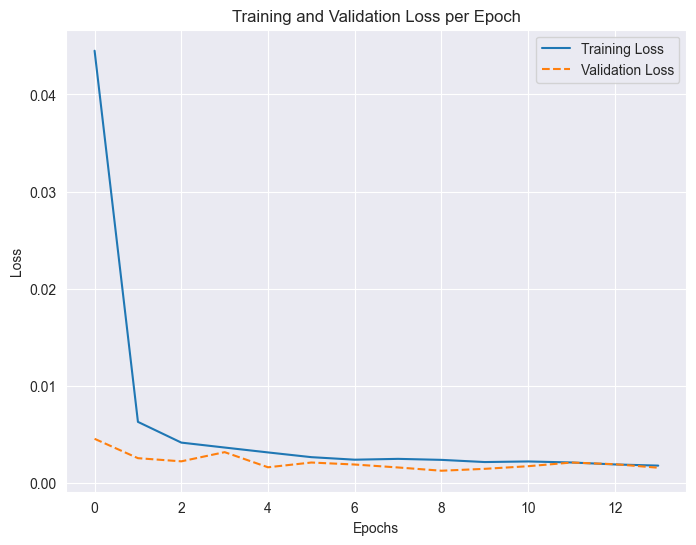

In [187]:
# Extract loss and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plotting training and validation loss
plt.figure(figsize=(8,6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='--')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1155/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 158us/step


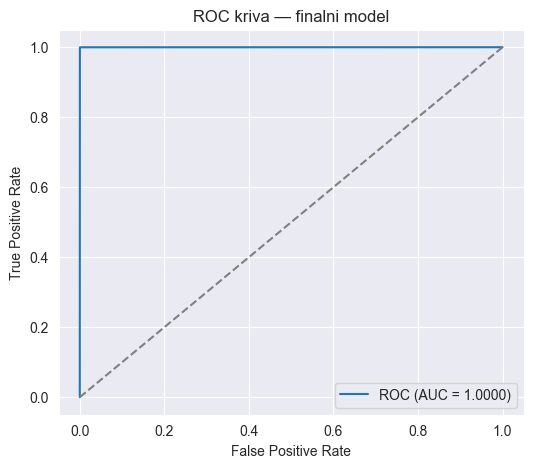

In [188]:
y_prob = model.predict(X_test_pt)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC kriva — finalni model')
plt.legend()
plt.show()

In [189]:
# Regenerate the classification report with 'output_dict=True'
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print(report_df)

              precision    recall  f1-score       support
0              0.999766  0.999298  0.999532  12823.000000
1              0.999627  0.999876  0.999751  24127.000000
accuracy       0.999675  0.999675  0.999675      0.999675
macro avg      0.999697  0.999587  0.999642  36950.000000
weighted avg   0.999675  0.999675  0.999675  36950.000000


## 4. Model Evaluation on Unseen Data

In [190]:
# path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

eval_df = pd.read_csv(Path().cwd() / 'data' / 'friday_ddos.csv')
eval_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [191]:
rename_dict = {
    "Destination Port": "Dst Port",
    "Flow Duration": "Flow Duration",
    "Total Fwd Packets": "Tot Fwd Pkts",
    "Total Backward Packets": "Tot Bwd Pkts",
    "Total Length of Fwd Packets": "TotLen Fwd Pkts",
    "Total Length of Bwd Packets": "TotLen Bwd Pkts",
    "Fwd Packet Length Max": "Fwd Pkt Len Max",
    "Fwd Packet Length Min": "Fwd Pkt Len Min",
    "Fwd Packet Length Mean": "Fwd Pkt Len Mean",
    "Fwd Packet Length Std": "Fwd Pkt Len Std",
    "Bwd Packet Length Max": "Bwd Pkt Len Max",
    "Bwd Packet Length Min": "Bwd Pkt Len Min",
    "Bwd Packet Length Mean": "Bwd Pkt Len Mean",
    "Bwd Packet Length Std": "Bwd Pkt Len Std",
    "Flow Bytes/s": "Flow Byts/s",
    "Flow Packets/s": "Flow Pkts/s",
    "Flow IAT Mean": "Flow IAT Mean",
    "Flow IAT Std": "Flow IAT Std",
    "Flow IAT Max": "Flow IAT Max",
    "Flow IAT Min": "Flow IAT Min",
    "Fwd IAT Total": "Fwd IAT Tot",
    "Fwd IAT Mean": "Fwd IAT Mean",
    "Fwd IAT Std": "Fwd IAT Std",
    "Fwd IAT Max": "Fwd IAT Max",
    "Fwd IAT Min": "Fwd IAT Min",
    "Bwd IAT Total": "Bwd IAT Tot",
    "Bwd IAT Mean": "Bwd IAT Mean",
    "Bwd IAT Std": "Bwd IAT Std",
    "Bwd IAT Max": "Bwd IAT Max",
    "Bwd IAT Min": "Bwd IAT Min",
    "Fwd PSH Flags": "Fwd PSH Flags",
    "Bwd PSH Flags": "Bwd PSH Flags",
    "Fwd URG Flags": "Fwd URG Flags",
    "Bwd URG Flags": "Bwd URG Flags",
    "Fwd Header Length": "Fwd Header Len",
    "Bwd Header Length": "Bwd Header Len",
    "Fwd Packets/s": "Fwd Pkts/s",
    "Bwd Packets/s": "Bwd Pkts/s",
    "Min Packet Length": "Pkt Len Min",
    "Max Packet Length": "Pkt Len Max",
    "Packet Length Mean": "Pkt Len Mean",
    "Packet Length Std": "Pkt Len Std",
    "Packet Length Variance": "Pkt Len Var",
    "FIN Flag Count": "FIN Flag Cnt",
    "SYN Flag Count": "SYN Flag Cnt",
    "RST Flag Count": "RST Flag Cnt",
    "PSH Flag Count": "PSH Flag Cnt",
    "ACK Flag Count": "ACK Flag Cnt",
    "URG Flag Count": "URG Flag Cnt",
    "CWE Flag Count": "CWE Flag Count",
    "ECE Flag Count": "ECE Flag Cnt",
    "Down/Up Ratio": "Down/Up Ratio",
    "Average Packet Size": "Pkt Size Avg",
    "Avg Fwd Segment Size": "Fwd Seg Size Avg",
    "Avg Bwd Segment Size": "Bwd Seg Size Avg",
    "Fwd Header Length.1": "toDrop",  # CICIDS duplikat, mapira se na isti naziv ili ga kasnije dropuješ
    "Fwd Avg Bytes/Bulk": "Fwd Byts/b Avg",
    "Fwd Avg Packets/Bulk": "Fwd Pkts/b Avg",
    "Fwd Avg Bulk Rate": "Fwd Blk Rate Avg",
    "Bwd Avg Bytes/Bulk": "Bwd Byts/b Avg",
    "Bwd Avg Packets/Bulk": "Bwd Pkts/b Avg",
    "Bwd Avg Bulk Rate": "Bwd Blk Rate Avg",
    "Subflow Fwd Packets": "Subflow Fwd Pkts",
    "Subflow Fwd Bytes": "Subflow Fwd Byts",
    "Subflow Bwd Packets": "Subflow Bwd Pkts",
    "Subflow Bwd Bytes": "Subflow Bwd Byts",
    "Init_Win_bytes_forward": "Init Fwd Win Byts",
    "Init_Win_bytes_backward": "Init Bwd Win Byts",
    "act_data_pkt_fwd": "Fwd Act Data Pkts",
    "min_seg_size_forward": "Fwd Seg Size Min",
    "Active Mean": "Active Mean",
    "Active Std": "Active Std",
    "Active Max": "Active Max",
    "Active Min": "Active Min",
    "Idle Mean": "Idle Mean",
    "Idle Std": "Idle Std",
    "Idle Max": "Idle Max",
    "Idle Min": "Idle Min",
    "Label": "target",
}

In [192]:
eval_df.columns = eval_df.columns.str.strip()

In [193]:
eval_df = eval_df.rename(columns=rename_dict)

In [194]:
eval_df.drop(columns=['toDrop', 'Dst Port'], inplace=True)

In [195]:
eval_df.drop(columns=constant_cols, inplace=True)

In [196]:
eval_df.shape

(225745, 65)

In [197]:
eval_df['target'].value_counts(normalize=True)

target
DDoS      0.567131
BENIGN    0.432869
Name: proportion, dtype: float64

In [198]:
eval_df["target"] = eval_df["target"].apply(lambda x: 1 if x == "DDoS" else 0)
eval_df['target'].value_counts(normalize=True)

target
1    0.567131
0    0.432869
Name: proportion, dtype: float64

In [199]:
eval_df.replace([np.inf, -np.inf], np.nan, inplace=True)
eval_df.dropna(inplace=True)
eval_df.reset_index(drop=True, inplace=True)
eval_df.shape

(225711, 65)

In [200]:
X_eval = eval_df.drop(columns=['target'])
y_eval = eval_df['target']

In [201]:
X_eval_pt = X_eval.copy()
X_eval_pt[transform_cols] = pt.transform(X_eval[transform_cols])

In [202]:
X_eval_pt[transform_cols] = X_eval_pt[transform_cols].clip(-CLIP_VAL, CLIP_VAL)

In [208]:
y_eval_pred = (model.predict(X_eval_pt) > 0.5).astype("int32")

7054/7054 ━━━━━━━━━━━━━━━━━━━━ 2s 252us/step


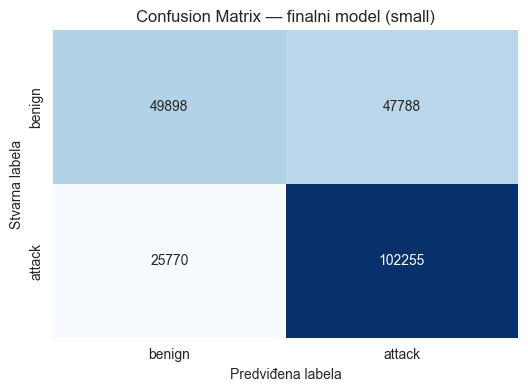

In [209]:
conf_matrix = confusion_matrix(y_eval, y_eval_pred)

plt.figure(figsize=(6,4))
sb.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['benign', 'attack'], yticklabels=['benign', 'attack'])
plt.title("Confusion Matrix — finalni model (small)")
plt.xlabel("Predviđena labela")
plt.ylabel("Stvarna labela")
plt.show()

In [210]:
print(classification_report(y_eval, y_eval_pred))

              precision    recall  f1-score   support

           0       0.66      0.51      0.58     97686
           1       0.68      0.80      0.74    128025

    accuracy                           0.67    225711
   macro avg       0.67      0.65      0.66    225711
weighted avg       0.67      0.67      0.67    225711

